# Phase 1 — Exploratory Data Analysis (USA / gold 24K / USD / 2017 → today)

Maps to the Phase-1 checklist in `refactor/02-data-understanding.md` and `project_plan.md`.

Scope is locked:
- Target metal/karat: **gold 24K** only (other karats and silver are excluded).
- Country: **USA** only.  Currency: **USD**.  Period: **2017-01-01 → today**.
- Exogenous sources: macro (FRED), market (VIX / oil), geopolitical (GDELT). `gold_reserves`
  (World Bank) is **dropped** — flagged in Phase 1 as a spurious co-trend feature.

Sections:
0. Setup — load 4 source tables, clean, merge + forward-fill → `usa_features`; null / type / describe checks
1. Trend visualization (univariate)
2. Correlation matrix vs the 13 exogenous features (multivariate)
3. Stationarity (ADF / KPSS) on level, first difference, log-returns
4. Autocorrelation (ACF / PACF)
5. STL decomposition (trend + seasonality + residual)
6. Geopolitical spikes vs gold-price moves
7. Missing-value analysis + imputation strategy
8. Forecast-horizon framing — T+1 → T+30 (one month ahead)

A light cleaning pass lives in Section 0; the full Data-Preparation cleanup is the next step
(`notebooks/cleaning.ipynb` / `USA_cleaning.py`).

In [ ]:
import sys, pathlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from db_settings import get_engine
warnings.filterwarnings('ignore')

## 0. Setup

In [ ]:
# Add repo root to sys.path so we can reuse db_settings.get_engine()
REPO_ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Scope constants from project_plan.md
DATE_START = pd.Timestamp('2014-01-01')   # exogenous warm-up floor (so forward-fill has prior obs)
GOLD_START = pd.Timestamp('2017-01-01')   # gold series / feature-frame floor
DATE_END = pd.Timestamp.today().normalize()
COUNTRY_ISO3 = 'USA'        # value used in geopo_data.country

# Feature lists (from project_plan.md — authoritative). gold_reserves dropped.
MACRO_FEATURES = ['fed_rate', 'real_rate', 'cpi', 'gdp', 'dxy', 'unemployment']
MARKET_FEATURES = ['vix', 'oil_price']
GEO_FEATURES = ['total_events', 'political_events', 'war_intensity', 'crisis_index', 'political_pressure']
ALL_EXOG_FEATURES = MACRO_FEATURES + MARKET_FEATURES + GEO_FEATURES

engine = get_engine()
print(f'Scope: {COUNTRY_ISO3} / gold_24k / USD / gold from {GOLD_START.date()} → {DATE_END.date()}')
print(f'Exogenous features ({len(ALL_EXOG_FEATURES)}): {ALL_EXOG_FEATURES}')

### 0a. Load USA gold price series → `usa_features`

`raw_prices` stores `date` as TEXT and holds all 12 countries; we filter `devise = 'USD'` and keep
**only `gold_24k`** (other karats + silver are out of scope). We cast the date in-memory and use the
raw values **as-is** (no per-day aggregation). This frame, `usa_features`, is the base we merge the
exogenous features into.

In [ ]:
price_raw = pd.read_sql(
    """
    SELECT date, gold_24k
    FROM raw_prices
    WHERE devise = %(devise)s
    """,
    engine,
    params={'devise': 'USD'},
)
print(f'Raw USA gold rows: {len(price_raw):,}')
price_raw['date'] = pd.to_datetime(price_raw['date'], errors='coerce')

# usa_features = gold_24k only, raw values as-is (no median-by-date dedup), sorted by date
usa_features = (price_raw[['date', 'gold_24k']]
                .dropna(subset=['date'])
                .sort_values('date')
                .reset_index(drop=True))
print(f'usa_features rows: {len(usa_features):,}')
print(f'Date span: {usa_features["date"].min().date()} → {usa_features["date"].max().date()}')
usa_features['gold_24k'].describe()

In [ ]:
# USD plausibility sanity check (24K spot ≈ $40–$90/g across 2017→2026)
median_price = usa_features['gold_24k'].median()
print(f'Median gold_24k = {median_price:.2f} (expected band 40–90 USD/g)')
if not (20 <= median_price <= 120):
    raise ValueError(f'gold_24k median {median_price:.2f} outside USD band — currency assumption broken')
print('✓ USD assumption looks plausible')

In [ ]:
usa_features.head(10)

### 0b. Load exogenous tables (USA scope)

In [6]:
# Macro (FRED, monthly) -- live table name is `Macroeconomic_data` (quoted); cols are mixed case.
macro = pd.read_sql(
    'SELECT date, fed_rate, real_rate, "CPI" AS cpi, "GDP" AS gdp, '
    '"DXY" AS dxy, "Unemployment" AS unemployment '
    'FROM "macro_data" WHERE date >= %(d)s AND date <= %(e)s ORDER BY date',
    engine,
    params={'d': DATE_START, 'e': DATE_END},
)
macro['date'] = pd.to_datetime(macro['date'])
# Dedupe: live `Macroeconomic_data` contains each row TWICE (FRED loader ran twice).
# Phase-2 cleanup fixes this at the DB level; for EDA we dedupe in-memory.
_before = len(macro)
macro = macro.drop_duplicates(subset='date', keep='first').sort_values('date').reset_index(drop=True)
print(f'Macro rows: {len(macro):,}  (dropped {_before - len(macro):,} duplicates)  '
      f'{macro["date"].min().date()} -> {macro["date"].max().date()}')
macro.head()

Macro rows: 2,741  (dropped 0 duplicates)  2016-01-01 -> 2026-05-15


,date,fed_rate,real_rate,cpi,gdp,dxy,unemployment
0,2016-01-01,0.34,0.734506,237.652,18525.933,NaN,4.8
1,2016-01-04,NaN,NaN,NaN,NaN,114.1595,NaN
2,2016-01-05,NaN,NaN,NaN,NaN,114.2649,NaN
3,2016-01-06,NaN,NaN,NaN,NaN,114.6177,NaN
4,2016-01-07,NaN,NaN,NaN,NaN,114.6516,NaN


In [7]:
# Market (Yahoo, daily) -- live cols are `"Date"` and `oil` (not `oil_price`).
market = pd.read_sql(
    'SELECT "Date" AS date, vix, oil AS oil_price FROM vix_oil_data '
    'WHERE "Date" >= %(d)s AND "Date" <= %(e)s ORDER BY "Date"',
    engine,
    params={'d': DATE_START, 'e': DATE_END},
)
market['date'] = pd.to_datetime(market['date'])
# Defensive dedupe (currently clean; protects against re-ingestion in future).
market = market.drop_duplicates(subset='date', keep='first').sort_values('date').reset_index(drop=True)
print(f'Market rows: {len(market):,}  {market["date"].min().date()} -> {market["date"].max().date()}')
market.head()

Market rows: 2,615  2016-01-04 -> 2026-05-25


,date,vix,oil_price
0,2016-01-04,20.700001,36.759998
1,2016-01-05,19.340000,35.970001
2,2016-01-06,20.590000,33.970001
3,2016-01-07,24.990000,33.270000
4,2016-01-08,27.010000,33.160000


In [8]:
# Geopolitical (GDELT, daily) -- live table name is `gdelt_data`.
geo = pd.read_sql(
    'SELECT date, total_events, political_events, war_intensity, crisis_index, political_pressure '
    'FROM geopo_data WHERE country = %(c)s AND date >= %(d)s AND date <= %(e)s ORDER BY date',
    engine,
    params={'c': COUNTRY_ISO3, 'd': DATE_START.date(), 'e': DATE_END.date()},
)
geo['date'] = pd.to_datetime(geo['date'])
# Defensive dedupe (currently clean; protects against re-ingestion in future).
geo = geo.drop_duplicates(subset='date', keep='first').sort_values('date').reset_index(drop=True)
print(f'Geo rows: {len(geo):,}  {geo["date"].min().date()} -> {geo["date"].max().date()}')
geo.head()

Geo rows: 3,797  2016-01-01 -> 2026-05-24


,date,total_events,political_events,war_intensity,crisis_index,political_pressure
0,2016-01-01,19589,5406,0.082087,0.319644,0.275971
1,2016-01-02,16265,4194,0.076606,0.435942,0.257854
2,2016-01-03,16740,4351,0.073716,0.350119,0.259916
3,2016-01-04,29041,7509,0.064254,0.479398,0.258565
4,2016-01-05,36073,9900,0.072353,0.301184,0.274443


### 0c. Merge exogenous features + forward-fill onto the trading-day grid

Monthly macro lands on month-starts and the daily market / geo sources have weekend / holiday gaps, so
we forward-fill each on a continuous daily calendar (warm-up from 2014 ensures early-2017 trading days
inherit a prior value), then project the result onto the USA gold trading days. The merged
`usa_features` is restricted to the locked scope (gold from 2017).

In [ ]:
# Continuous daily calendar across the warm-up window; forward-fill each source on it
cal = pd.DataFrame({'date': pd.date_range(DATE_START, DATE_END, freq='D')})
cal = cal.merge(macro, on='date', how='left')
for c in MACRO_FEATURES:
    cal[c] = cal[c].ffill()
cal = cal.merge(market[['date'] + MARKET_FEATURES], on='date', how='left')
for c in MARKET_FEATURES:
    cal[c] = cal[c].ffill()
cal = cal.merge(geo[['date'] + GEO_FEATURES], on='date', how='left')
for c in GEO_FEATURES:
    cal[c] = cal[c].ffill()

# Project forward-filled exogenous values onto the gold trading-day grid, then lock to 2017+
usa_features = usa_features.merge(cal, on='date', how='left')
usa_features = usa_features[usa_features['date'] >= GOLD_START].reset_index(drop=True)
print(f'usa_features shape: {usa_features.shape}  (1 target + {len(ALL_EXOG_FEATURES)} exogenous)')
print(f'Date span: {usa_features["date"].min().date()} → {usa_features["date"].max().date()}')
usa_features.head()

### 0d. Sanity checks — null values, column types, statistics

In [ ]:
# Null values per column (post forward-fill)
usa_features.isna().sum()

In [ ]:
# Column types
usa_features.dtypes

In [ ]:
# Descriptive statistics
usa_features.describe()

## 1. Gold 24K price trend (USA, 2017 → today)

Task 1 from `project_plan.md` PHASE 1.

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(usa_features['date'], usa_features['gold_24k'], lw=1.2, color='goldenrod')
ax.set_title('USA gold 24K (USD per gram) — 2017 → today', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('USD / g')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Reference regime shifts
events = {
    '2020-03-11': 'COVID shock',
    '2022-06-02': 'Inflation peak',
    '2024-11-05': 'US election',
}
for d, label in events.items():
    ts = pd.Timestamp(d)
    if usa_features['date'].min() <= ts <= usa_features['date'].max():
        ax.axvline(ts, ls='--', color='gray', lw=0.8)
        ax.text(ts, ax.get_ylim()[1]*0.97, label, rotation=90, va='top', ha='right', fontsize=8, color='gray')
plt.tight_layout(); plt.show()
print(f'Min: {usa_features["gold_24k"].min():.2f}   Max: {usa_features["gold_24k"].max():.2f}   '
      f'Range start→end: {usa_features["gold_24k"].iloc[0]:.2f} → {usa_features["gold_24k"].iloc[-1]:.2f} USD/g')

**Verdict — Task 1**: read the trend chart above and note: overall direction (up / flat / down), notable drawdowns or rallies aligned with the marked regime events, and any obvious outliers worth investigating in Phase 2 cleanup.

## 2. Correlation matrix — `gold_24k` vs the exogenous features (multivariate)

Task 2 from `project_plan.md` PHASE 1. Computed on the merged, forward-filled `usa_features`
(13 exogenous features; `gold_reserves` dropped). Levels are strongly trending, so high
correlations here are partly co-trend — confirmed against returns / SHAP at the modeling step.

In [ ]:
import jinja2  # noqa: F401 (enables Styler.background_gradient)
# Pearson + Spearman correlation of each exogenous feature with gold_24k
rows = []
for c in ALL_EXOG_FEATURES:
    pearson_r, pearson_p = stats.pearsonr(usa_features['gold_24k'], usa_features[c])
    spear_r, spear_p = stats.spearmanr(usa_features['gold_24k'], usa_features[c])
    rows.append({'feature': c, 'pearson': pearson_r, 'pearson_p': pearson_p,
                 'spearman': spear_r, 'spearman_p': spear_p})
corr_df = pd.DataFrame(rows).sort_values('pearson', key=abs, ascending=False).reset_index(drop=True)
corr_df.style.background_gradient(subset=['pearson', 'spearman'], cmap='RdBu_r', vmin=-1, vmax=1)

In [ ]:
# Full correlation heatmap (all features + gold_24k)
cm = usa_features[['gold_24k'] + ALL_EXOG_FEATURES].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Pearson correlation — gold_24k and exogenous features', fontsize=12)
plt.tight_layout(); plt.show()

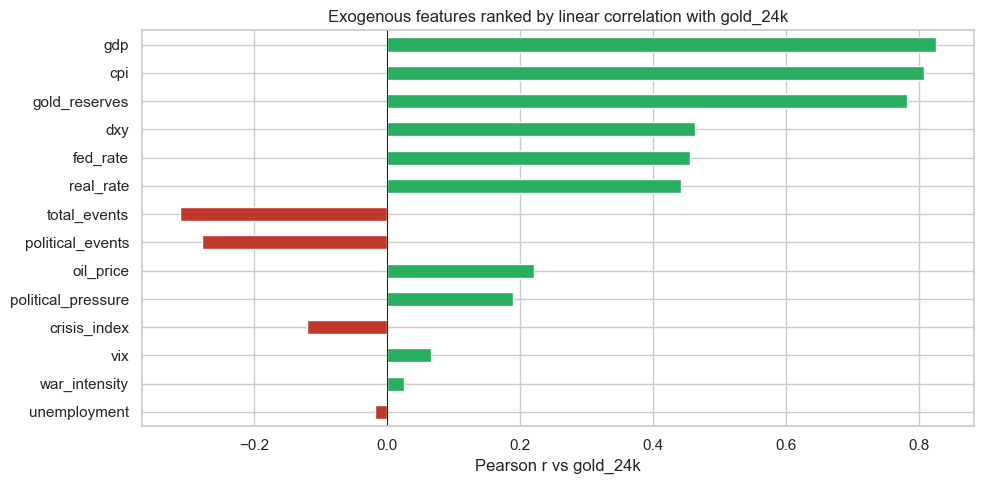

In [15]:
# Ranked bar chart of |Pearson r| vs gold_24k
fig, ax = plt.subplots(figsize=(10, 5))
ranked = corr_df.set_index('feature')['pearson']
colors = ['#c0392b' if v < 0 else '#27ae60' for v in ranked]
ranked.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel('Pearson r vs gold_24k'); ax.set_ylabel('')
ax.set_title('Exogenous features ranked by linear correlation with gold_24k')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

**Verdict — Task 2**: list the top 3 |ρ| features (likely candidates for SHAP-confirmed importance in Phase 3) and call out any with |ρ| < 0.1 that could be dropped to reduce noise (though we'll keep them in `ml.us_gold_features_daily` per the project_plan spec).

## 3. Stationarity — ADF + KPSS on level, first difference, log-returns

Task 3 from `project_plan.md` PHASE 1. Both tests run on three transformations to find a transformation where ADF rejects a unit root **and** KPSS does not reject stationarity.

In [ ]:
y = usa_features.set_index('date')['gold_24k'].astype(float)
transforms = {
    'level':        y,
    'first_diff':   y.diff().dropna(),
    'log_returns':  np.log(y / y.shift(1)).dropna(),
}

def adf_kpss(series):
    adf_stat, adf_p, *_ = adfuller(series, autolag='AIC')
    # KPSS warns; suppress
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')
    return adf_stat, adf_p, kpss_stat, kpss_p

rows = []
for name, s in transforms.items():
    a_stat, a_p, k_stat, k_p = adf_kpss(s)
    rows.append({
        'transform': name,
        'ADF stat': a_stat, 'ADF p': a_p,
        'ADF says': 'stationary' if a_p < 0.05 else 'non-stationary',
        'KPSS stat': k_stat, 'KPSS p': k_p,
        'KPSS says': 'stationary' if k_p > 0.05 else 'non-stationary',
    })
stat_df = pd.DataFrame(rows)
stat_df

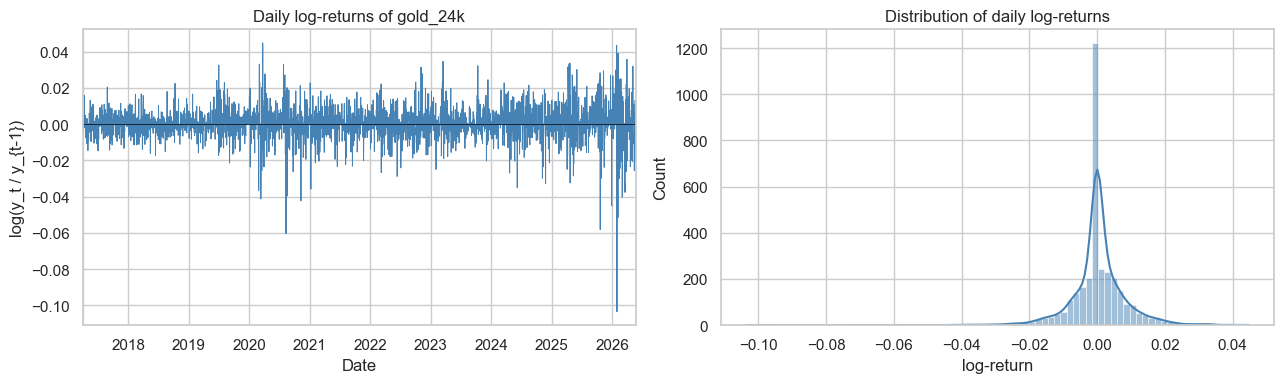

In [17]:
# Visualize the log-returns distribution (typical modeling target for ARIMA on log-prices)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
transforms['log_returns'].plot(ax=axes[0], color='steelblue', lw=0.7)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('Daily log-returns of gold_24k')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('log(y_t / y_{t-1})')

sns.histplot(transforms['log_returns'], kde=True, bins=80, ax=axes[1], color='steelblue')
axes[1].set_title('Distribution of daily log-returns')
axes[1].set_xlabel('log-return')
plt.tight_layout(); plt.show()

**Verdict — Task 3**: pick the transform where both tests agree on stationary (typically `log_returns` for asset prices). This is the modeling target for ARIMA/SARIMA in Phase 3.

## 4. Autocorrelation — ACF / PACF

Autocorrelation of the price *level* (expected to decay slowly → unit root / strong persistence)
versus the *log-returns* (expected ≈ white noise at h = 1 → little linear structure to exploit).
This is the empirical basis for the "daily gold ≈ random walk" finding.

In [ ]:
y_lr = np.log(y / y.shift(1)).dropna()
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_acf(y, lags=40, ax=axes[0, 0]); axes[0, 0].set_title('ACF — gold_24k level')
plot_pacf(y, lags=40, ax=axes[0, 1], method='ywm'); axes[0, 1].set_title('PACF — gold_24k level')
plot_acf(y_lr, lags=40, ax=axes[1, 0]); axes[1, 0].set_title('ACF — daily log-returns')
plot_pacf(y_lr, lags=40, ax=axes[1, 1], method='ywm'); axes[1, 1].set_title('PACF — daily log-returns')
plt.tight_layout(); plt.show()

## 5. STL decomposition (trend + seasonality + residual)

Task 4 from `project_plan.md` PHASE 1. Period = 365 (daily series, calendar year).

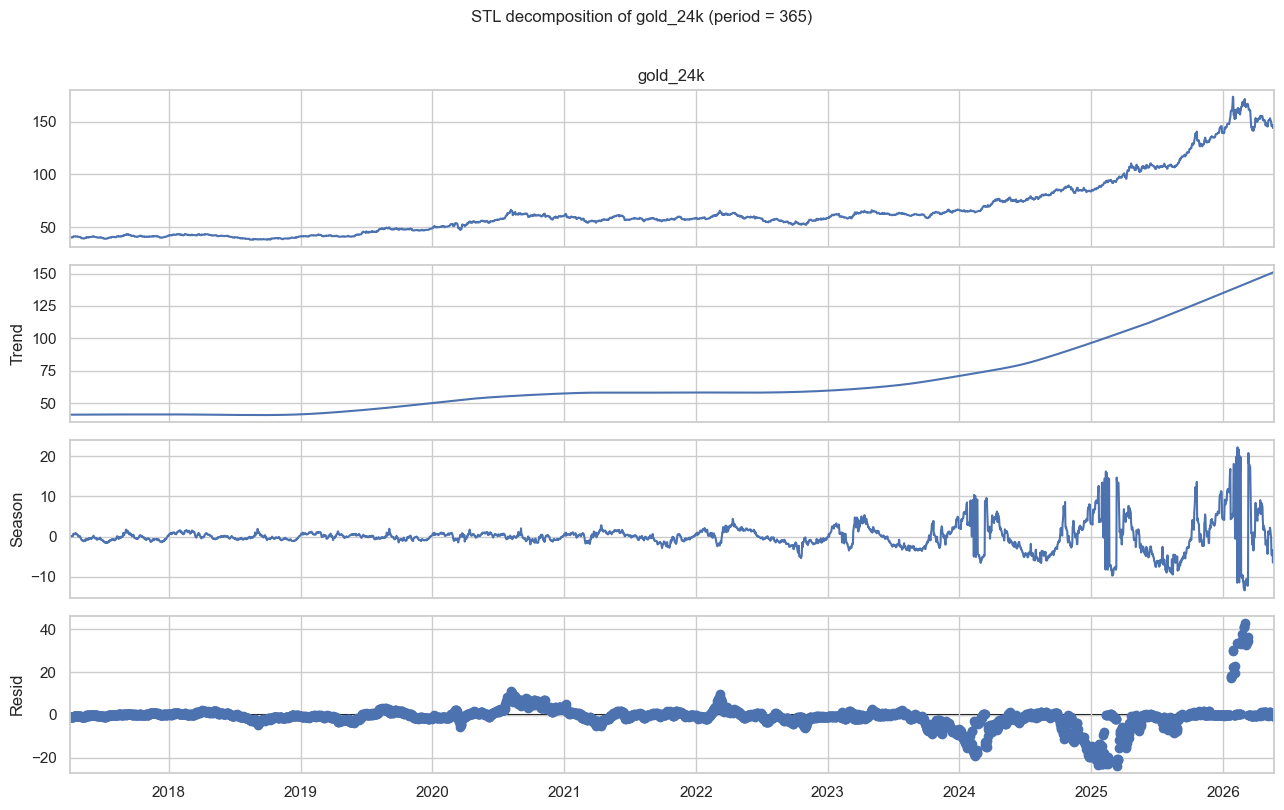

Component standard deviations:
trend       27.553642
seasonal     3.453491
residual     5.225235
dtype: float64

Seasonal range: -13.39 → 22.20 USD/g
Trend range:    40.87 → 151.17 USD/g


In [18]:
stl = STL(y, period=365, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(13, 8)
fig.suptitle('STL decomposition of gold_24k (period = 365)', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

# Quantify component magnitudes
components = pd.DataFrame({'trend': stl.trend, 'seasonal': stl.seasonal, 'residual': stl.resid})
print('Component standard deviations:')
print(components.std())
print(f'\nSeasonal range: {components["seasonal"].min():.2f} → {components["seasonal"].max():.2f} USD/g')
print(f'Trend range:    {components["trend"].min():.2f} → {components["trend"].max():.2f} USD/g')

**Verdict — Task 4**: compare the std of trend vs seasonal vs residual. For gold, trend usually dominates; seasonal amplitude is typically small relative to the trend's swing. Note whether the seasonal pattern is strong enough to warrant SARIMA over plain ARIMA in Phase 3.

## 6. Geopolitical event spikes vs gold-price moves

Task 5 from `project_plan.md` PHASE 1. A "spike" = day where USA `crisis_index` or `war_intensity`
exceeds its 99th percentile across the window.

In [ ]:
geo_window = usa_features[['date', 'crisis_index', 'war_intensity']].copy()
thresh_crisis = geo_window['crisis_index'].quantile(0.99)
thresh_war = geo_window['war_intensity'].quantile(0.99)
spikes = geo_window[(geo_window['crisis_index'] >= thresh_crisis) |
                    (geo_window['war_intensity'] >= thresh_war)].copy()
print(f'Crisis-index 99th pct = {thresh_crisis:.3f}   |   War-intensity 99th pct = {thresh_war:.3f}')
print(f'Spike days identified: {len(spikes):,}')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(usa_features['date'], usa_features['gold_24k'], color='goldenrod', lw=1.2, label='gold_24k')
for d in spikes['date']:
    ax.axvline(d, color='crimson', alpha=0.12, lw=0.8)
ax.set_title(f'Gold 24K with USA geopolitical spikes (top 1% of crisis_index or war_intensity, n={len(spikes)})')
ax.set_xlabel('Date'); ax.set_ylabel('USD / g')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

In [ ]:
# Compare 7-day forward return after a spike vs baseline
p = (usa_features[['date', 'gold_24k']]
     .drop_duplicates(subset='date', keep='last')
     .set_index('date')['gold_24k'])
fwd_ret_7 = (p.shift(-7) / p - 1) * 100

spike_dates = pd.DatetimeIndex(spikes['date'].unique()).intersection(fwd_ret_7.index)
ret_after_spike = fwd_ret_7.loc[spike_dates].dropna()
ret_baseline = fwd_ret_7.dropna()

print(f'7-day forward return AFTER a spike:   mean {ret_after_spike.mean():+.2f}%   '
      f'median {ret_after_spike.median():+.2f}%   n={len(ret_after_spike)}')
print(f'7-day forward return baseline (all):  mean {ret_baseline.mean():+.2f}%      '
      f'median {ret_baseline.median():+.2f}%      n={len(ret_baseline)}')

from scipy.stats import mannwhitneyu
if len(ret_after_spike) > 0:
    u_stat, u_p = mannwhitneyu(ret_after_spike, ret_baseline, alternative='greater')
    print(f'Mann-Whitney U (one-sided, after-spike > baseline): U={u_stat:.0f}, p={u_p:.4f}')
else:
    print('No spike dates after intersection -- nothing to test.')

**Verdict — Task 5**: state whether the post-spike 7-day return is higher than baseline and whether the U test rejects the null at α = 0.05. This is preliminary evidence — Phase 3 SHAP will be the final word on whether geopolitical features actually drive the model.

## 7. Missing-value analysis + imputation strategy

Task 6 from `project_plan.md` PHASE 1. The forward-fill decision for weekend / holiday gold-price gaps
is already locked in `refactor/02-data-understanding.md` § Decisions.

In [ ]:
# Per-source missingness on the daily calendar (pre forward-fill) — 4 sources, no reserves
raw_frame = (
    pd.DataFrame({'date': pd.date_range(GOLD_START, DATE_END, freq='D')})
    .merge(usa_features[['date', 'gold_24k']], on='date', how='left')
    .merge(macro, on='date', how='left')
    .merge(market[['date'] + MARKET_FEATURES], on='date', how='left')
    .merge(geo[['date'] + GEO_FEATURES], on='date', how='left')
)
miss = pd.DataFrame({
    'null_count': raw_frame.drop(columns=['date']).isna().sum(),
    'null_pct':   raw_frame.drop(columns=['date']).isna().mean() * 100,
}).sort_values('null_pct', ascending=False)
miss

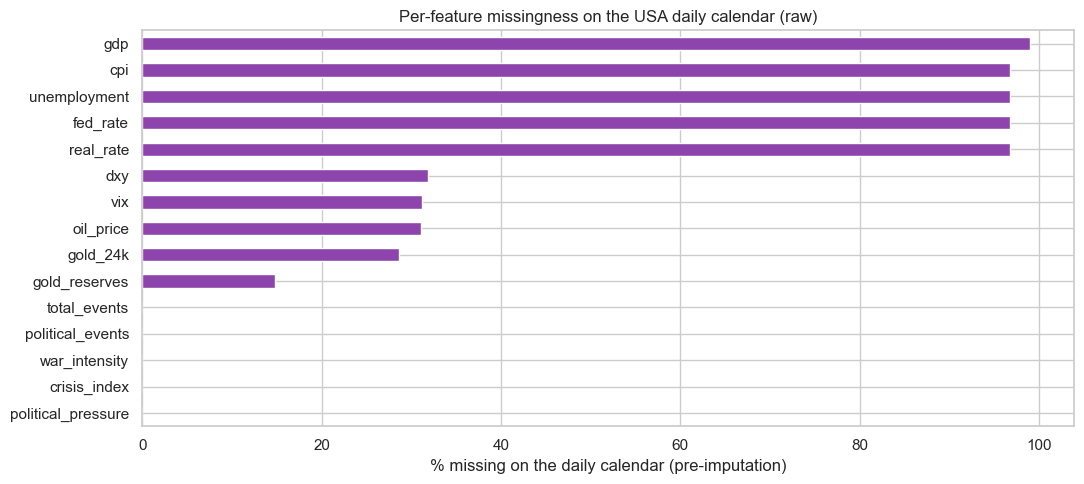

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
miss['null_pct'].plot(kind='barh', color='#8e44ad', ax=ax)
ax.set_xlabel('% missing on the daily calendar (pre-imputation)')
ax.set_title('Per-feature missingness on the USA daily calendar (raw)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

In [ ]:
# Gold-price-gap profile: distribution of gap lengths in the USA trading-day series
gaps = usa_features['date'].diff().dt.days.dropna()
gap_summary = gaps.value_counts().sort_index().head(15)
print('Gap-length distribution (days between consecutive USA price observations):')
print(gap_summary.to_string())
print(f'\nMax gap: {gaps.max()} days   |   Median gap: {gaps.median()} days')
print('Gaps of 2–3 days are weekends; longer gaps include US holidays (Thanksgiving, Christmas).')

**Verdict — Task 6 (imputation strategy):**

| Source          | Native grain | Imputation rule                                   |
|-----------------|--------------|----------------------------------------------------|
| `raw_prices`    | Daily (gaps) | Forward-fill weekend / holiday gaps (gold series)  |
| `macro_data`    | Monthly      | Forward-fill month → daily                         |
| `vix_oil_data`  | Daily (gaps) | Forward-fill weekend / holiday gaps                |
| `geopo_data`    | Daily        | Dense for USA; ffill any sporadic missing days     |

`gold_reserves` (World Bank, annual) is **dropped** from the feature set (spurious co-trend). This
matches the forward-fill applied in Section 0 and locks the strategy that Data Preparation implements
at the feature-table level.

## 8. Forecast-horizon framing — T+1 → T+30 (one month ahead)

Phase-3 modeling at **h = 1** found daily gold ≈ a random walk — every model tied to the naive
"tomorrow = today" baseline. We therefore re-frame the task at **h = 30 trading days** (~one month).
The view below is deliberately **target-agnostic**: we characterise the 30-day-ahead relationship both
as a price *level* `y(t+30)` and as a 30-day cumulative *log-return* `ln(y(t+30)/y(t))`. The exact
modeling target (level vs return) is locked at the modeling step — see `project_plan.md`.

In [ ]:
H = 30  # trading days ahead (~1 month)
y = usa_features.set_index('date')['gold_24k'].astype(float)
y_fwd = y.shift(-H)                       # price level h days ahead
fwd_logret = np.log(y_fwd / y)            # 30-day cumulative log-return

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y, y_fwd, s=6, alpha=0.3, color='goldenrod')
axes[0].set_title(f'Level view — y(t) vs y(t+{H})')
axes[0].set_xlabel('y(t)  [USD/g]'); axes[0].set_ylabel(f'y(t+{H})  [USD/g]')
axes[0].text(0.05, 0.95, f'Pearson r = {y.corr(y_fwd):.3f}', transform=axes[0].transAxes, va='top')

sns.histplot(fwd_logret.dropna(), kde=True, bins=60, ax=axes[1], color='steelblue')
axes[1].axvline(0, color='black', lw=0.6)
axes[1].set_title(f'Return view — {H}-day forward log-return')
axes[1].set_xlabel(f'ln(y(t+{H}) / y(t))')
plt.tight_layout(); plt.show()
print(f'{H}-day forward log-return: mean {fwd_logret.mean():+.4f}   std {fwd_logret.std():.4f}   '
      f'n={fwd_logret.dropna().shape[0]}')

**Verdict — horizon:** the level view is highly persistent (a near-diagonal cloud → trending), while
the return view shows the dispersion of monthly moves the model must actually predict. At h = 30 the
slow-moving macro / market / geo features have more room to carry signal than at t+1, where the series
is ≈ a random walk. Whether we model the **level** `y(t+30)` or the **cumulative return**
`ln(y(t+30)/y(t))` — and the exact feature set — is decided at the modeling step (see `project_plan.md`).

## Hand-off to the main cleaning step (Data Preparation)

This notebook does a **light** in-memory clean to support the EDA; the persisted cleanup is the next
step (`notebooks/cleaning.ipynb` / `USA_cleaning.py`). Items surfaced here to carry forward:

1. `raw_prices.date` is **TEXT** → convert to `DATE`; `raw_prices.country` is a French slug → ISO3.
2. `macro_data` columns are mixed-case (`"CPI"`, `"GDP"`, `"DXY"`, `"Unemployment"`) → lowercase to
   match the feature contract; `vix_oil_data` uses `"Date"` / `oil` → `date` / `oil_price`.
3. Gold-series outlier (max ≈ 173.62 $/g) is well above plausible 24K spot — decide capping /
   winsorization in cleaning.
4. **`gold_reserves` is dropped** from the Stage-1 feature set (spurious co-trend). The source table
   `reserves_gold` stays, but `USA_cleaning.py` / `models/utils.py` / `ml.us_gold_features_daily`
   still carry it — align them in the main cleaning step.
5. Forecast horizon moves **T+1 → T+30**; the modeling target representation is locked at the
   modeling step.